Датасэт с прослушиванием популярных музыкальных артистов.В нём стобцы представляют собой артистов ,а строки - пользователей некоторой музыкальной площадки со статистикой,сколько времени данный пользователь слушал данного артиста за конечный промежуток времени.

Ссылка на Kaggle - https://www.kaggle.com/datasets/thedatasetengineer/user-listen-time-music-streaming-history?resource=download



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('user_music_listen_data.csv')
df.head()

,User_ID,T_Swift,Drake,Queen,The_Weeknd,Eminem,Nirvana,Ed_Sheeran,T_Scott,Linkin_Park,Dua_Lipa,K_Lamar,Imag_Dragons,Ariana_G
0,User_1001,53.0,0.0,87.0,102.0,0.0,92.0,112.0,79.0,64.0,0.0,49.0,212.0,112.0
1,User_1002,144.0,NaN,53.0,194.0,31.0,44.0,150.0,47.0,45.0,213.0,47.0,232.0,157.0
2,User_1003,182.0,47.0,64.0,203.0,75.0,44.0,213.0,93.0,19.0,180.0,103.0,199.0,176.0
3,User_1004,136.0,45.0,0.0,97.0,40.0,0.0,NaN,62.0,15.0,105.0,73.0,190.0,111.0
4,User_1005,110.0,33.0,52.0,127.0,51.0,23.0,57.0,0.0,0.0,98.0,66.0,124.0,66.0


In [2]:
df.tail()

,User_ID,T_Swift,Drake,Queen,The_Weeknd,Eminem,Nirvana,Ed_Sheeran,T_Scott,Linkin_Park,Dua_Lipa,K_Lamar,Imag_Dragons,Ariana_G
448,User_1449,66.0,0.0,82.0,115.0,46.0,NaN,142.0,91.0,130.0,82.0,22.0,301.0,0.0
449,User_1450,208.0,0.0,40.0,144.0,20.0,52.0,178.0,41.0,47.0,172.0,47.0,170.0,165.0
450,User_1451,36.0,40.0,42.0,15.0,92.0,123.0,14.0,0.0,59.0,0.0,13.0,164.0,62.0
451,User_1452,74.0,19.0,63.0,116.0,67.0,109.0,0.0,20.0,120.0,134.0,39.0,227.0,113.0
452,User_1453,0.0,NaN,0.0,70.0,62.0,20.0,24.0,66.0,0.0,38.0,129.0,63.0,25.0


In [3]:
df.info()
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   User_ID       453 non-null    object 
 1   T_Swift       444 non-null    float64
 2   Drake         439 non-null    float64
 3   Queen         441 non-null    float64
 4   The_Weeknd    442 non-null    float64
 5   Eminem        444 non-null    float64
 6   Nirvana       435 non-null    float64
 7   Ed_Sheeran    449 non-null    float64
 8   T_Scott       441 non-null    float64
 9   Linkin_Park   443 non-null    float64
 10  Dua_Lipa      445 non-null    float64
 11  K_Lamar       438 non-null    float64
 12  Imag_Dragons  439 non-null    float64
 13  Ariana_G      440 non-null    float64
dtypes: float64(13), object(1)
memory usage: 49.7+ KB


,T_Swift,Drake,Queen,The_Weeknd,Eminem,Nirvana,Ed_Sheeran,T_Scott,Linkin_Park,Dua_Lipa,K_Lamar,Imag_Dragons,Ariana_G
count,444.00,439.00,441.00,442.00,444.00,435.00,449.00,441.00,443.00,445.00,438.00,439.00,440.00
mean,60.33,60.15,68.92,114.53,63.87,59.95,80.13,61.19,66.73,73.45,74.96,159.34,66.46
std,60.62,62.06,54.38,66.97,53.11,48.39,63.91,51.89,51.06,56.68,59.20,83.78,53.82
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,19.00,14.00,26.00,68.25,22.75,19.00,27.00,19.00,27.50,29.00,32.00,101.00,23.00
50%,46.00,46.00,63.00,110.00,58.00,55.00,71.00,51.00,62.00,72.00,66.00,158.00,59.00
75%,83.25,86.50,104.00,156.75,97.00,89.50,119.00,95.00,98.00,107.00,110.75,211.00,99.00
max,374.00,403.00,307.00,336.00,255.00,253.00,312.00,212.00,301.00,303.00,281.00,469.00,249.00


In [4]:
print("Размер:", df.shape)
print("\nПропуски:")
print(df.isnull().sum())
print("\nДубликаты:", df.duplicated().sum())

Размер: (453, 14)

Пропуски:
User_ID          0
T_Swift          9
Drake           14
Queen           12
The_Weeknd      11
Eminem           9
Nirvana         18
Ed_Sheeran       4
T_Scott         12
Linkin_Park     10
Dua_Lipa         8
K_Lamar         15
Imag_Dragons    14
Ariana_G        13
dtype: int64

Дубликаты: 0


In [5]:
artists = df.drop(columns='User_ID')

stats = pd.DataFrame({
    'Mean':   artists.mean().round(2),
    'Median': artists.median().round(2),
    'Mode':   artists.mode().iloc[0].round(2)
})
stats

,Mean,Median,Mode
T_Swift,60.33,46.0,0.0
Drake,60.15,46.0,0.0
Queen,68.92,63.0,0.0
The_Weeknd,114.53,110.0,0.0
Eminem,63.87,58.0,0.0
Nirvana,59.95,55.0,0.0
Ed_Sheeran,80.13,71.0,0.0
T_Scott,61.19,51.0,0.0
Linkin_Park,66.73,62.0,0.0
Dua_Lipa,73.45,72.0,0.0


Заполнение пропусков в таблице значением median(медианой) ,так как если заполнять, няпример, mean, то при наличии выбросов,которые тоже учитываются при подсчёте mean, пропуски будут заполняться менее точными значениеями.если бы мы,например, заполняли пропуски медианой,которая не настолько сильно "страдает" от выбросов,то получили бы более точные данные для заполнения пропусков.

In [6]:
df_clean = df.copy()
df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)

print("Пропуски после обработки:")
print(df_clean.isnull().sum())

Пропуски после обработки:
User_ID         0
T_Swift         0
Drake           0
Queen           0
The_Weeknd      0
Eminem          0
Nirvana         0
Ed_Sheeran      0
T_Scott         0
Linkin_Park     0
Dua_Lipa        0
K_Lamar         0
Imag_Dragons    0
Ariana_G        0
dtype: int64


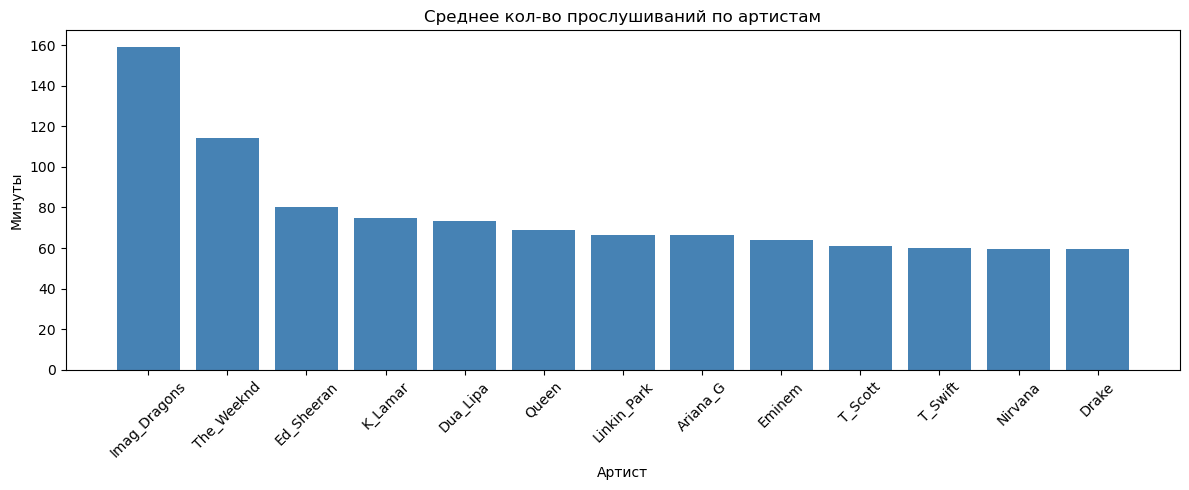

In [7]:
means = df_clean.drop(columns='User_ID').mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(means.index, means.values, color='steelblue')
plt.title('Среднее кол-во прослушиваний по артистам')
plt.xlabel('Артист')
plt.ylabel('Минуты')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

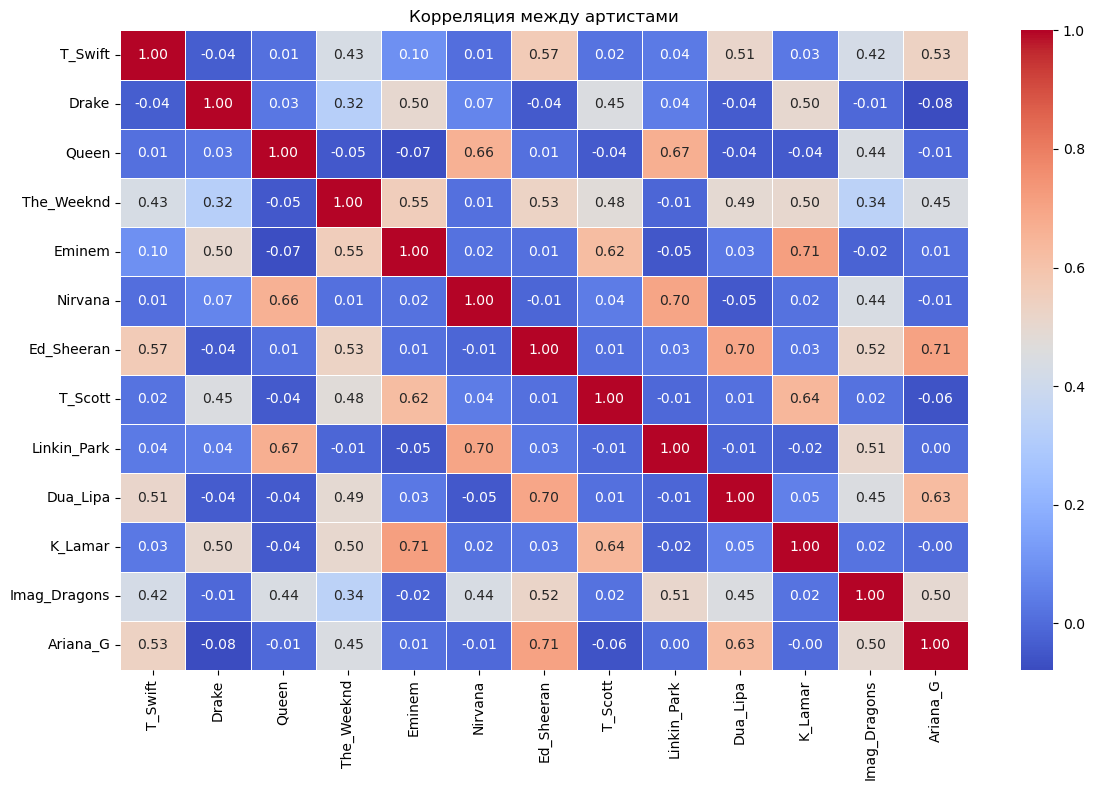

In [8]:
plt.figure(figsize=(12, 8))
corr = df_clean.drop(columns='User_ID').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Корреляция между артистами')
plt.tight_layout()
plt.show()

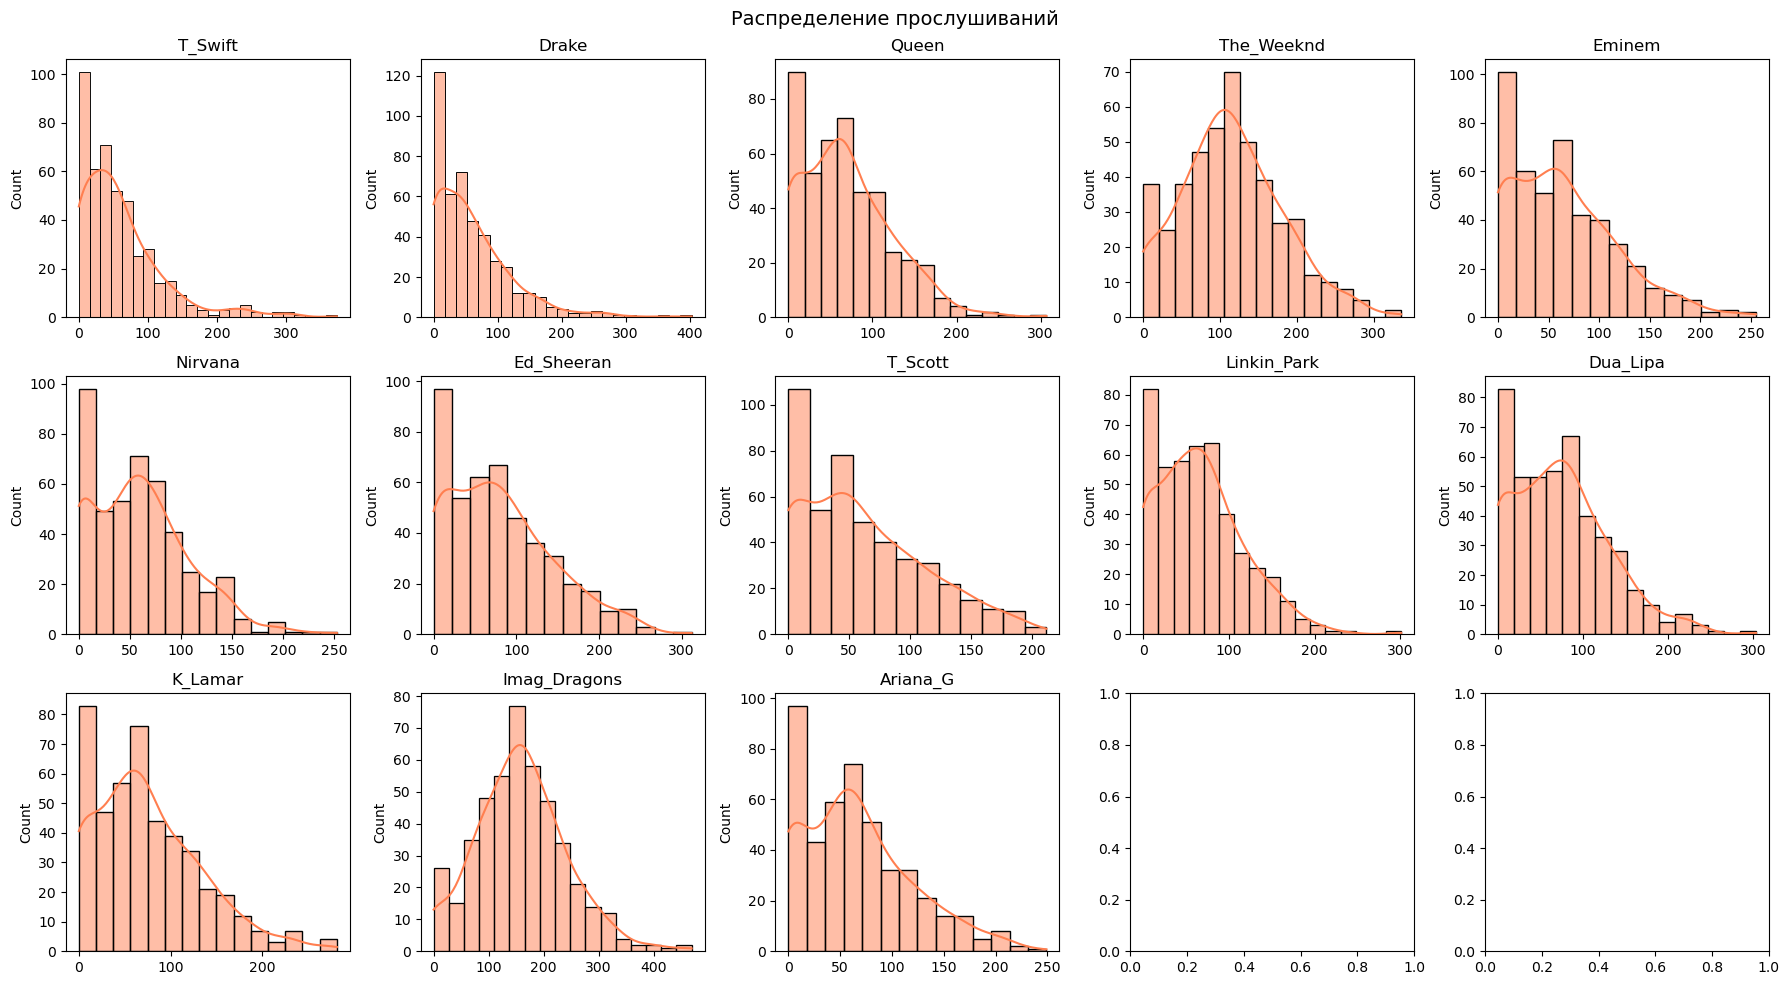

In [9]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()
artists_cols = df_clean.drop(columns='User_ID').columns

for i, col in enumerate(artists_cols):
    sns.histplot(df_clean[col], ax=axes[i], kde=True, color='coral')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Распределение прослушиваний', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
artists = df_clean.drop(columns='User_ID')

advanced_stats = pd.DataFrame({
    'Дисперсия':  artists.var().round(2),
    'Асимметрия':  artists.skew().round(2),
    'Эксцесс':  artists.kurtosis().round(2)
})

advanced_stats

,Дисперсия,Асимметрия,Эксцесс
T_Swift,3605.82,1.83,4.40
Drake,3738.61,1.73,4.43
Queen,2879.55,0.81,0.73
The_Weeknd,4376.36,0.38,-0.01
Eminem,2765.09,0.83,0.46
Nirvana,2249.21,0.73,0.45
Ed_Sheeran,4049.33,0.72,0.02
T_Scott,2623.29,0.70,-0.25
Linkin_Park,2549.74,0.79,0.77
Dua_Lipa,3155.37,0.70,0.37


Дисперсия показывает,насколько у нас разбросаны данные на графике.
Ассиметрия показывает куда перекошен график ,если вправо - то большинство слушало мало данного артиста.
Эксцесс показывает острый или не острый пик у графика,то есть есть ли фанаты-экстремалы, например, у Imagine Dragons.

In [11]:
means = df_clean.drop(columns='User_ID').mean().sort_values(ascending=False).reset_index()
means.columns = ['Артист', 'Среднее']

fig = px.bar(means, x='Артист', y='Среднее',
             title='Популярность артистов (среднее прослушиваний)',
             color='Среднее', color_continuous_scale='Blues')
fig.show()

In [12]:
df_melt = df_clean.drop(columns='User_ID').melt(var_name='Артист', value_name='Минуты')

fig = px.box(df_melt, x='Артист', y='Минуты',
             title='Разброс прослушиваний по артистам',
             color='Артист')
fig.show()

In [13]:
artists = df_clean.drop(columns=['User_ID', 'total'], errors='ignore')

# Гипотеза 1: Кто самый популярный артист?
print("Самый популярный артист:")
print(artists.mean().idxmax(), "-", round(artists.mean().max(), 2), "мин")

# Гипотеза 2: Кто наименее популярен?
print("\nНаименее популярный артист:")
print(artists.mean().idxmin(), "-", round(artists.mean().min(), 2), "мин")

# Гипотеза 3: Есть ли пользователи которые слушают только 1 артиста?
only_one = (artists > 0).sum(axis=1) == 1
print(f"\nПользователей с 1 артистом: {only_one.sum()}")

# Гипотеза 4: Слушатели Eminem часто слушают Linkin_Park?
corr_val = artists['Eminem'].corr(artists['Linkin_Park'])
print(f"\nКорреляция Eminem ↔ Linkin_Park: {corr_val:.2f}")

# Гипотеза 5: Топ-3 артиста у самых активных слушателей (топ 10%)
df_clean['total'] = artists.sum(axis=1)
top_users = df_clean[df_clean['total'] >= df_clean['total'].quantile(0.9)]
top_artists = top_users.drop(columns=['User_ID', 'total']).mean().sort_values(ascending=False)
print("\nТоп-3 артиста у активных слушателей:")
print(top_artists.head(3))

Самый популярный артист:
Imag_Dragons - 159.3 мин

Наименее популярный артист:
Drake - 59.71 мин

Пользователей с 1 артистом: 0

Корреляция Eminem ↔ Linkin_Park: -0.05

Топ-3 артиста у активных слушателей:
Imag_Dragons    270.282609
The_Weeknd      206.652174
Ed_Sheeran      163.673913
dtype: float64


In [14]:
genres = ['rock', 'pop', 'hip-hop']
df['genre'] = np.resize(genres, len(df))

print("ДО кодирования:")
df[['User_ID', 'genre']].head(6)

ДО кодирования:


,User_ID,genre
0,User_1001,rock
1,User_1002,pop
2,User_1003,hip-hop
3,User_1004,rock
4,User_1005,pop
5,User_1006,hip-hop


In [15]:
# Кодируем
df_encoded = pd.get_dummies(df, columns=['genre'], prefix='genre')

print("ПОСЛЕ кодирования:")
df_encoded[['User_ID', 'genre_rock', 'genre_pop', 'genre_hip-hop']].head(6)

ПОСЛЕ кодирования:


,User_ID,genre_rock,genre_pop,genre_hip-hop
0,User_1001,True,False,False
1,User_1002,False,True,False
2,User_1003,False,False,True
3,User_1004,True,False,False
4,User_1005,False,True,False
5,User_1006,False,False,True


In [16]:
df_encoded[['User_ID', 'genre_rock', 'genre_pop', 'genre_hip-hop']].tail(6)

,User_ID,genre_rock,genre_pop,genre_hip-hop
447,User_1448,True,False,False
448,User_1449,False,True,False
449,User_1450,False,False,True
450,User_1451,True,False,False
451,User_1452,False,True,False
452,User_1453,False,False,True


In [17]:
artists_cols = ['T_Swift','Drake','Queen','The_Weeknd','Eminem',
                'Nirvana','Ed_Sheeran','T_Scott','Linkin_Park',
                'Dua_Lipa','K_Lamar','Imag_Dragons','Ariana_G']

# Фича 1 — Суммарные минуты (насколько активен пользователь)
df['total_minutes'] = df[artists_cols].sum(axis=1)

# Фича 2 — Кол-во артистов которых слушал (разнообразие вкусов)
df['artists_count'] = (df[artists_cols] > 0).sum(axis=1)

# Фича 3 — Рок vs Поп (какой стиль предпочитает)
df['rock_score'] = df['Nirvana'] + df['Linkin_Park'] + df['Queen']
df['pop_score']  = df['T_Swift'] + df['Ariana_G'] + df['Dua_Lipa']
df['rock_vs_pop'] = df['rock_score'] / (df['pop_score'] + 1)

# Смотрим результат
df[['User_ID','total_minutes','artists_count','rock_vs_pop']].head(6)

,User_ID,total_minutes,artists_count,rock_vs_pop
0,User_1001,962.0,10,1.463855
1,User_1002,1357.0,12,0.275728
2,User_1003,1598.0,13,0.235622
3,User_1004,874.0,10,0.042493
4,User_1005,807.0,11,0.272727
5,User_1006,545.0,9,3.430769


In [18]:
df[['User_ID','total_minutes','artists_count','rock_vs_pop']].tail(6)

,User_ID,total_minutes,artists_count,rock_vs_pop
447,User_1448,1575.0,13,4.911111
448,User_1449,1077.0,10,NaN
449,User_1450,1284.0,12,0.254579
450,User_1451,660.0,11,2.262626
451,User_1452,1101.0,12,0.906832
452,User_1453,497.0,9,0.312500


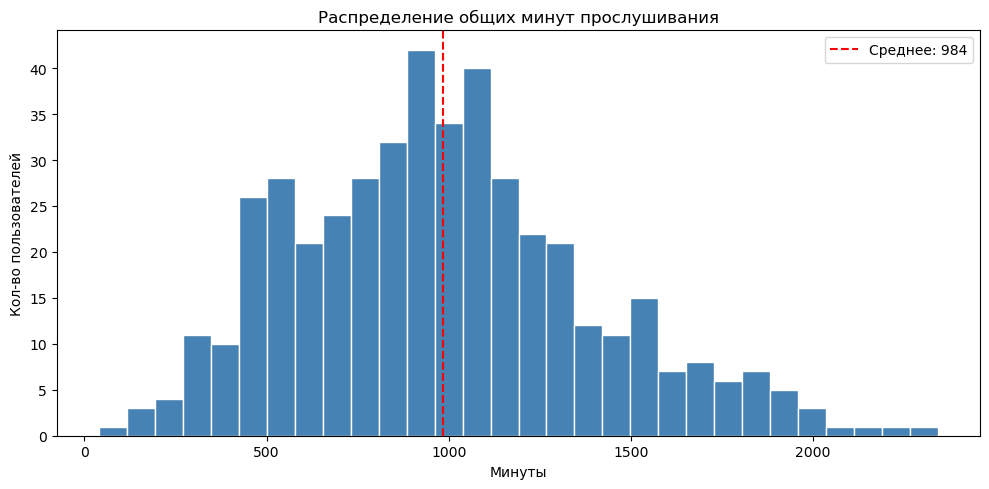

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(df['total_minutes'].dropna(), bins=30, color='steelblue', edgecolor='white')
plt.axvline(df['total_minutes'].mean(), color='red', linestyle='--', label=f"Среднее: {df['total_minutes'].mean():.0f}")
plt.title('Распределение общих минут прослушивания')
plt.xlabel('Минуты')
plt.ylabel('Кол-во пользователей')
plt.legend()
plt.tight_layout()
plt.show()

Общие минуты (total_minutes) — это сумма всех прослушиваний одного пользователя по всем артистам.

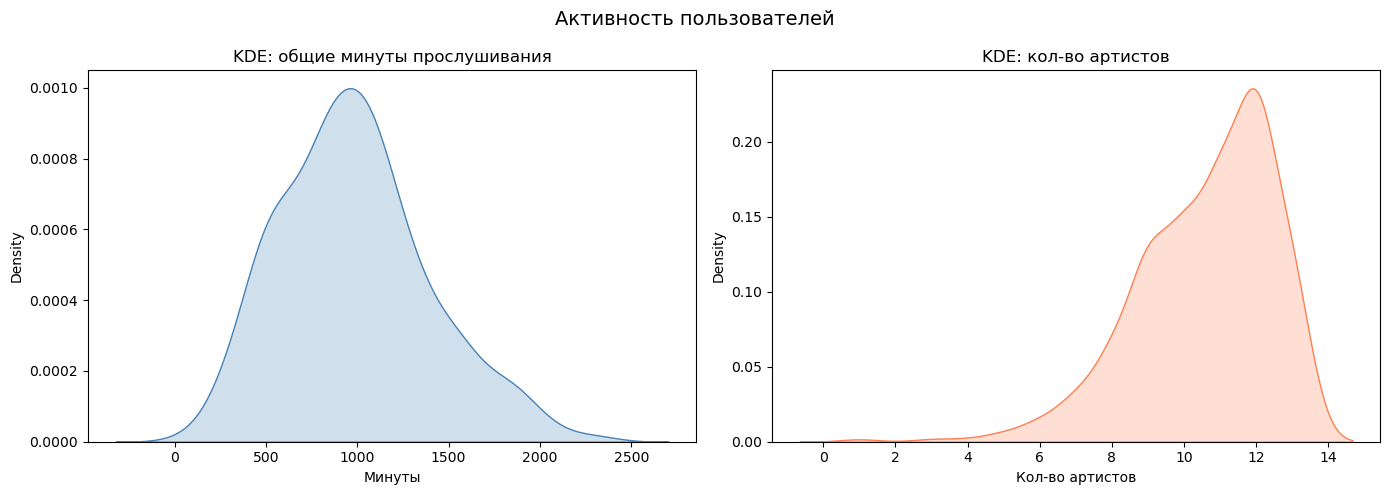

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1 — total_minutes
sns.kdeplot(df['total_minutes'].dropna(), fill=True, color='steelblue', ax=axes[0])
axes[0].set_title('KDE: общие минуты прослушивания')
axes[0].set_xlabel('Минуты')

# График 2 — artists_count
sns.kdeplot(df['artists_count'].dropna(), fill=True, color='coral', ax=axes[1])
axes[1].set_title('KDE: кол-во артистов')
axes[1].set_xlabel('Кол-во артистов')

plt.suptitle('Активность пользователей', fontsize=14)
plt.tight_layout()
plt.show()

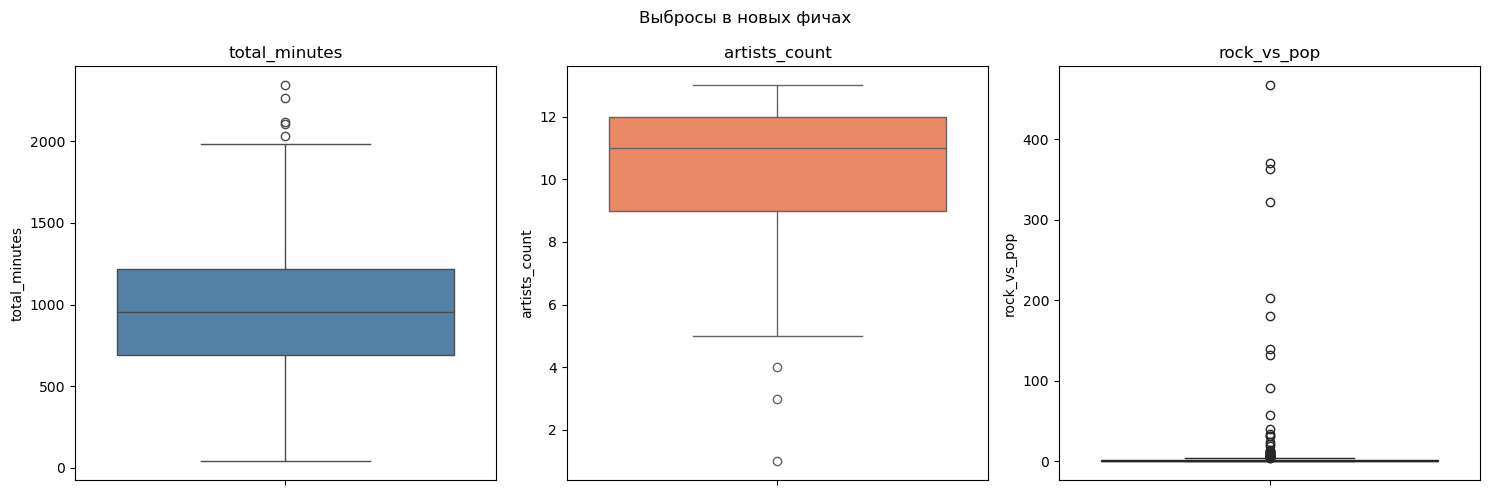

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df['total_minutes'],   ax=axes[0], color='steelblue')
axes[0].set_title('total_minutes')

sns.boxplot(y=df['artists_count'],   ax=axes[1], color='coral')
axes[1].set_title('artists_count')

sns.boxplot(y=df['rock_vs_pop'],     ax=axes[2], color='green')
axes[2].set_title('rock_vs_pop')

plt.suptitle('Выбросы в новых фичах')
plt.tight_layout()
plt.show()

У большинства пользователей pop_score больше чем rock_score — поп популярнее рока в датасете. Поэтому rock / pop даёт маленькие числа (0-2)

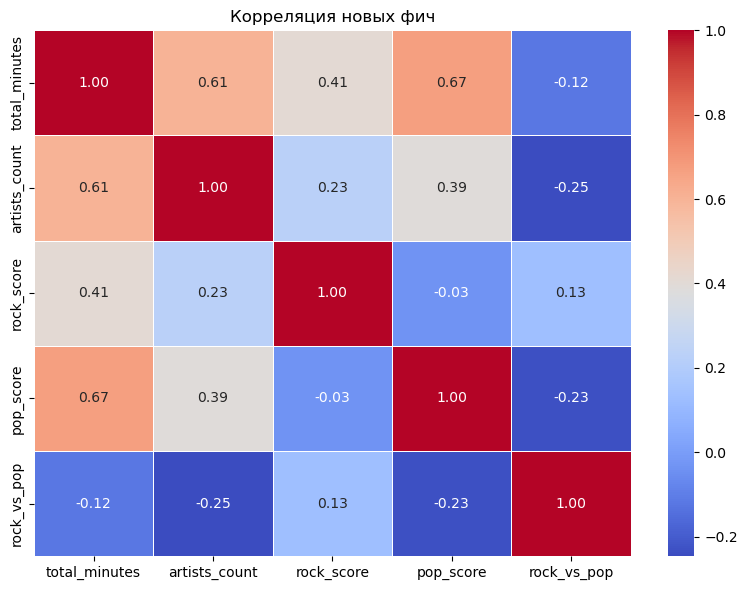

In [22]:
new_features = df[['total_minutes', 'artists_count', 'rock_score', 'pop_score', 'rock_vs_pop']].dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(new_features.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Корреляция новых фич')
plt.tight_layout()
plt.show()

In [23]:
fig = px.scatter(df,
                 x='artists_count',
                 y='total_minutes',
                 color='genre',
                 hover_data=['User_ID', 'rock_vs_pop'],
                 title='Активность пользователей по жанрам',
                 labels={'artists_count': 'Кол-во артистов',
                         'total_minutes': 'Общие минуты'})
fig.show()

Что я понял про датасэт:
 - Имея 13 столбцов и 452 строки мы можем увидеть всю информацию о прослушиваниях музыкальных артистов
 - Все пользователей можно кластеризовать на 3 крупных кластера - Рок, Поп, Хип-хоп(Рэп).
 - Многие пользователи в датасэте имеют 0 прослушиваний некоторых артистов,так что эти нули были заменеены на медиану.
 - Самый популярный артист - Imagine dragons.
 - Самый не популярный артист - Drake.
 - Самая большая кореляция среди артистов - у Kendrick Lamar и Eminem.
 - В датасете много выбросов.
 - Нету пользователей, которые слушали только 1 артиста
 - Среднее количество общих минут у пользователей - 984.

Гипотезы и наблюдения:
 - Самые большие кореляции стреди артистов - у Kendrick Lamar и Eminem и у Ed Sheren и Ariana Grande (0.71) , получается ,что слушатели Kendrick Lamar также предпочитают слушать и Eminem(И наоборот),а слушатели Ed Sheren также предпочитают Ariana Grande(и наоборот).Наименьшая же кореляция у Drake и Ariana Grande (-0.07) , это значит ,что слушатели Drake реже всего слушают Ariana Grande (И наоборот),что вроде логично,так как Дрейк - рэпер, а Ариана Гранде - поп-певица.
 - Самая большая дисперсия - у Imagine Dragons (6802.31) то есть у них больше всего разброс слушателей по минутам прослушивания - есть те ,кто слушал много,а также есть и те кто слушал совсем немного.
 - Самая большая ассиметрия - у Tailor Swift и Drake, то есть график имеех хвост справа,который показывает ,что у них большая часть слушателей слушают их в большом количестве.

Можно было бы взять модель для кластеризации пользователей по жанрам.
Если платформа имеет функцию добавления в друзья,то можно было бы построить рекомендательную систему 
,которая будет рекомендовать пользователем артистов,которые могли бы им понравиться,исходя из предпочтений их друзей.

Я просил у нейронки конспекты по всем темам,разбирал их и просил привести код для датасета,некоторые аспекты дописывались самостоятельно,например,
вывод начала и конца таблицы, основную инфу, графики и диаграммы мне предоставила нейронка,все выводы,гипотезы и умозаключения были составлены мной 
исходя из теории,полученной от нейронки для конспекта в obsidian и исходя из всех графиков и диаграмм.
